In [8]:
import pandas as pd
import numpy as np
import os
import joblib 
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn Imports
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import OrdinalEncoder

# Set plotting style for consistent output
sns.set_style("whitegrid")

In [9]:
# --- 1. Settings and Data Loading (Defining the DataFrame) ---
print("--- Starting 05 Quick Baseline Model & Feature Importance (Scikit-learn DTR) ---")

# Define the relative path to the cleaned Parquet file created in 03_final_prep.ipynb
# This structure assumes the script is run from a notebook folder (e.g., /notebooks/05...)
PROCESSED_DATA_PATH = './../../data/electricity/processed/demand_model_ready.parquet'
MODEL_PATH = './../../data/trained_models/electricity/'

try:
    # Use pandas (pd) to load the model-ready DataFrame. This defines the 'df' variable.
    resolved_path = os.path.normpath(PROCESSED_DATA_PATH)
    print(f"1. Loading cleaned data from resolved path: {resolved_path}")
    df = pd.read_parquet(resolved_path)
    print(f"   -> Data successfully loaded. Total records: {len(df):,}")
    
    # Check if the dataframe is empty after loading
    if df.empty:
        raise ValueError("Loaded DataFrame is empty. Check 03_final_prep.ipynb output.")

except FileNotFoundError:
    print(f"   -> ERROR: File not found at {PROCESSED_DATA_PATH}. Please run 03_final_prep.ipynb first.")
    exit()
except Exception as e:
    print(f"   -> An error occurred during data loading: {e}")
    exit()


--- Starting 05 Quick Baseline Model & Feature Importance (Scikit-learn DTR) ---
1. Loading cleaned data from resolved path: ../../data/electricity/processed/demand_model_ready.parquet
   -> Data successfully loaded. Total records: 434,590


In [38]:
df['SETTLEMENT_DATE'] = pd.to_datetime(df['SETTLEMENT_DATE'])

# Calendar features
df['sale_month'] = df['SETTLEMENT_DATE'].dt.month
df['Day'] = df['SETTLEMENT_DATE'].dt.day
df['DayOfWeek'] = df['SETTLEMENT_DATE'].dt.dayofweek
df['sale_year'] = df['SETTLEMENT_DATE'].dt.year

# Target
y = np.log(df['ND'])

# Predictors (safe for forecasting)
features = ['sale_month', 'Day', 'DayOfWeek', 'SETTLEMENT_PERIOD', 'sale_year']
X = df[features].copy()

# Identify categorical columns
categorical_features = [col for col in X.columns if X[col].dtype.name == 'category']

In [39]:
# -------------------------------
# 3. ENCODING
# -------------------------------
print("\nEncoding categorical features...")

encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
if categorical_features:
    X[categorical_features] = encoder.fit_transform(X[categorical_features])

print("   -> Encoding complete.")


Encoding categorical features...
   -> Encoding complete.


In [40]:

# -------------------------------
# 4. TIME-SERIES SPLIT (NO SHUFFLE)
# -------------------------------
print("\nPerforming Time-Series Aware Train/Test Split (80/20)...")

# VERY IMPORTANT: Sort chronologically
df = df.sort_values("SETTLEMENT_DATE").reset_index(drop=True)
X = X.loc[df.index]
y = y.loc[df.index]

split_idx = int(len(df) * 0.8)

X_train = X.iloc[:split_idx]
y_train = y.iloc[:split_idx]

X_test = X.iloc[split_idx:]
y_test = y.iloc[split_idx:]

print(f"   -> Training samples: {len(X_train):,}")
print(f"   -> Testing samples:  {len(X_test):,}")


Performing Time-Series Aware Train/Test Split (80/20)...
   -> Training samples: 347,672
   -> Testing samples:  86,918


In [41]:
# -------------------------------
# 5. MODEL TRAINING
# -------------------------------
print("\nTraining Decision Tree Regressor (baseline, max_depth=10)...")

dtr_reg = DecisionTreeRegressor(
    max_depth=10,
    random_state=42
)

dtr_reg.fit(X_train, y_train)
print("   -> Training complete.")


Training Decision Tree Regressor (baseline, max_depth=10)...
   -> Training complete.


In [42]:

# -------------------------------
# 6. MODEL EVALUATION
# -------------------------------
print("\nEvaluating model...")

y_pred_log = dtr_reg.predict(X_test)

# Convert back to MW
y_test_demand = np.exp(y_test)
y_pred_demand = np.exp(y_pred_log)

rmse_demand = np.sqrt(mean_squared_error(y_test_demand, y_pred_demand))
mae_demand = mean_absolute_error(y_test_demand, y_pred_demand)
r2_demand = r2_score(y_test_demand, y_pred_demand)

rmse_log = np.sqrt(mean_squared_error(y_test, y_pred_log))
r2_log = r2_score(y_test, y_pred_log)

print("\n--- Evaluation Metrics ---")
print(f"R² (log scale)          : {r2_log:.4f}")
print(f"RMSE (log scale)        : {rmse_log:.4f}")
print("-"*50)
print(f"R² (demand MW)          : {r2_demand:.4f}")
print(f"RMSE (demand MW)        : {rmse_demand:,.2f}")
print(f"MAE (demand MW)         : {mae_demand:,.2f}")
print("-"*50)

print("\nFirst 5 predictions:")
print(pd.DataFrame({
    "Actual (MW)": y_test_demand[:5].values,
    "Predicted (MW)": y_pred_demand[:5]
}))


Evaluating model...

--- Evaluation Metrics ---
R² (log scale)          : 0.7053
RMSE (log scale)        : 0.1237
--------------------------------------------------
R² (demand MW)          : 0.6991
RMSE (demand MW)        : 3,397.08
MAE (demand MW)         : 2,589.88
--------------------------------------------------

First 5 predictions:
   Actual (MW)  Predicted (MW)
0      31983.0    34489.382516
1      33674.0    34489.382516
2      27798.0    28936.359267
3      27728.0    31228.968068
4      21895.0    25304.883811



Generating residual plots...


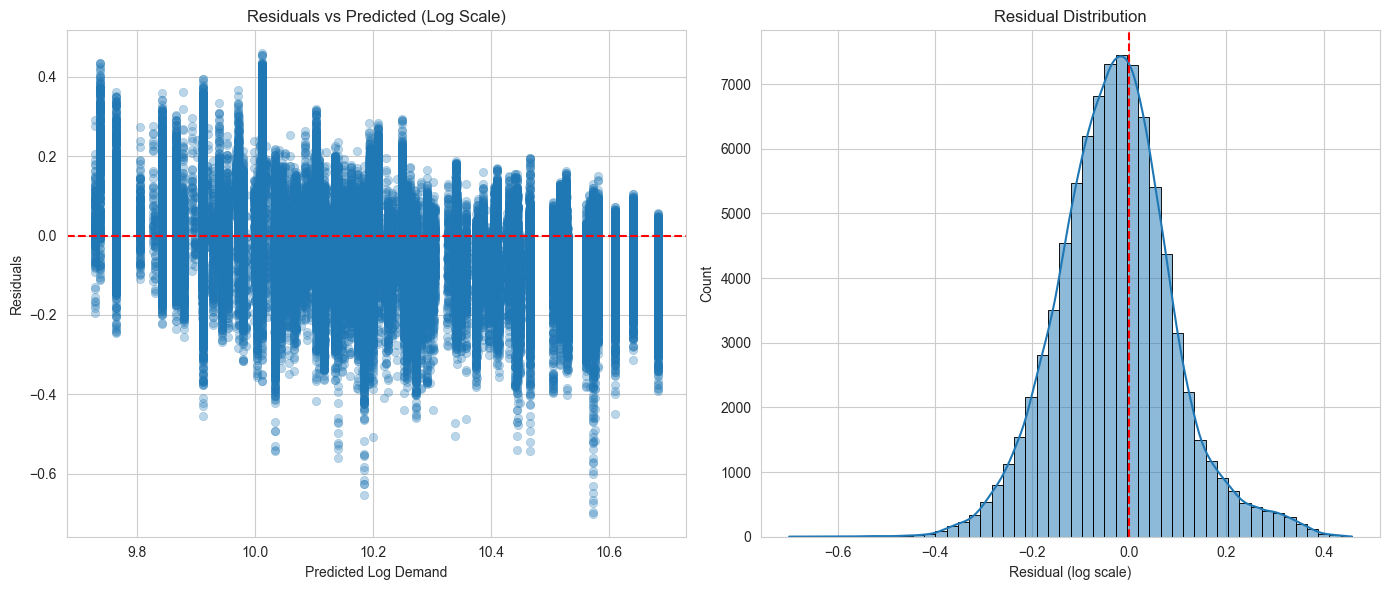


Residual summary:
count    86918.0000
mean        -0.0290
std          0.1203
min         -0.7003
25%         -0.1049
50%         -0.0292
75%          0.0418
max          0.4584
Name: ND, dtype: float64


In [43]:
# -------------------------------
# 6b. RESIDUAL ANALYSIS
# -------------------------------
print("\nGenerating residual plots...")

residuals = y_test - y_pred_log

plt.figure(figsize=(14, 6))

# Plot 1: Residuals vs Predicted
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_pred_log, y=residuals, alpha=0.3, edgecolor=None)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residuals vs Predicted (Log Scale)")
plt.xlabel("Predicted Log Demand")
plt.ylabel("Residuals")

# Plot 2: Residual distribution
plt.subplot(1, 2, 2)
sns.histplot(residuals, kde=True, bins=50, edgecolor='black')
plt.axvline(0, color='red', linestyle='--')
plt.title("Residual Distribution")
plt.xlabel("Residual (log scale)")

plt.tight_layout()
plt.show()

print("\nResidual summary:")
print(residuals.describe().round(4))


Computing feature importance...


/var/folders/6z/vs2gqd6s6zx7b6vqyq8nbwrh0000gn/T/ipykernel_60897/106540004.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=importance_df, palette="viridis")


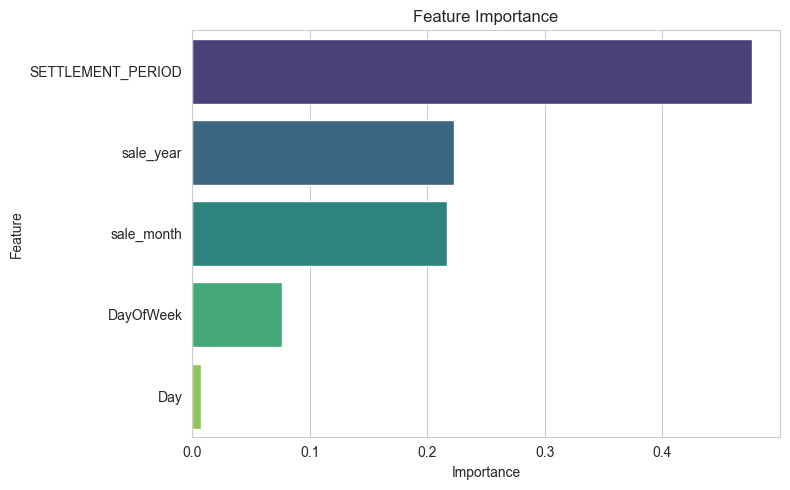


Feature Importance (%):
          Feature  Importance (%)
SETTLEMENT_PERIOD           47.62
        sale_year           22.28
       sale_month           21.71
        DayOfWeek            7.67
              Day            0.73


In [44]:
# -------------------------------
# 7. FEATURE IMPORTANCE
# -------------------------------
print("\nComputing feature importance...")

importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": dtr_reg.feature_importances_
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x="Importance", y="Feature", data=importance_df, palette="viridis")
plt.title("Feature Importance")
plt.tight_layout()
plt.show()

print("\nFeature Importance (%):")
importance_df["Importance (%)"] = (importance_df["Importance"] * 100).round(2)
print(importance_df[["Feature", "Importance (%)"]].to_string(index=False))

In [45]:
# -------------------------------
# 8. SAVE MODEL
# -------------------------------
model_dir = os.path.dirname(MODEL_PATH)
save_path = os.path.join(model_dir, "dtr_baseline_model.joblib")
joblib.dump(dtr_reg, save_path)

print(f"\nModel saved to: {save_path}")


Model saved to: ./../../data/trained_models/electricity/dtr_baseline_model.joblib


In [46]:
df.head()

,SETTLEMENT_DATE,SETTLEMENT_PERIOD,ND,TSD,ENGLAND_WALES_DEMAND,EMBEDDED_WIND_GENERATION,EMBEDDED_WIND_CAPACITY,EMBEDDED_SOLAR_GENERATION,EMBEDDED_SOLAR_CAPACITY,NON_BM_STOR,...,ELECLINK_FLOW,VIKING_FLOW,GREENLINK_FLOW,Year,ND_log,Month,Day,DayOfWeek,sale_month,sale_year
0,2001-01-01,1,38631,0.0,34060.0,0.0,0.0,0.0,0.0,0,...,0.0,0.0,0.0,2001,10.561836,1,1,0,1,2001
1,2001-01-01,36,41855,0.0,37705.0,0.0,0.0,0.0,0.0,0,...,0.0,0.0,0.0,2001,10.641990,1,1,0,1,2001
2,2001-01-01,24,34951,0.0,31276.0,0.0,0.0,0.0,0.0,0,...,0.0,0.0,0.0,2001,10.461731,1,1,0,1,2001
3,2001-01-01,2,39808,0.0,35370.0,0.0,0.0,0.0,0.0,0,...,0.0,0.0,0.0,2001,10.591848,1,1,0,1,2001
4,2001-01-01,3,40039,0.0,35680.0,0.0,0.0,0.0,0.0,0,...,0.0,0.0,0.0,2001,10.597634,1,1,0,1,2001
